# Brain Stroke Detection using Deep Learning and Optimization Techniques

This project aims to detect brain stroke from CT scan images using a hybrid pipeline:

- Feature Extraction: InceptionV3 (Deep CNN)
- Dimensionality Reduction: PCA
- Feature Selection: Genetic Algorithm (GAFeatureSelectionCV)
- Classification: Random Forest

## Pipeline:
1. Load dataset
2. Visualize dataset
3. Train-test split
4. CNN feature extraction
5. PCA
6. Genetic Algorithm feature selection
7. Random Forest classification
8. Evaluation

## Import Libraries

In [ ]:
!pip install sklearn_genetic

In [ ]:
!pip install sklearn-genetic

In [ ]:
!pip install sklearn-genetic-opt

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import pickle

from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn_genetic import GAFeatureSelectionCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, accuracy_score

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array

from sklearn_genetic import GAFeatureSelectionCV

import warnings
warnings.filterwarnings('ignore')

## Load Dataset

### Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Set Dataset Path

In [ ]:
dataset_path = "/content/drive/MyDrive/Updated_Dataset_MiniProject"

categories = ["Normal", "Stroke"]

print("Dataset path set:", dataset_path)

Dataset path set: /content/drive/MyDrive/Updated_Dataset_MiniProject


### Verify Dataset Structure

In [ ]:
for category in categories:
    path = os.path.join(dataset_path, category)
    print(category, "->", len(os.listdir(path)), "images")

Normal -> 11844 images
Stroke -> 3052 images


### Load and Preprocess Images

In [ ]:
'''data = []
labels = []

IMG_SIZE = 224

for category in categories:
    path = os.path.join(dataset_path, category)
    label = categories.index(category)

    for root, dirs, files in os.walk(path):  # 🔥 This is the fix
        for img in files:
            try:
                img_path = os.path.join(root, img)

                image = load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
                image = img_to_array(image)
                image = preprocess_input(image)

                data.append(image)
                labels.append(label)

            except Exception as e:
                continue

data = np.array(data, dtype="float32")
labels = np.array(labels)

print("Dataset loaded successfully!")
print("Shape:", data.shape)'''

import os
import pandas as pd

image_paths = []
image_labels = []

categories = ["Normal", "Stroke"]

for category in categories:
    category_path = os.path.join(dataset_path, category)
    label = categories.index(category)

    for root, dirs, files in os.walk(category_path):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')):
                image_paths.append(os.path.join(root, file))
                image_labels.append(label)

df = pd.DataFrame({
    "filepath": image_paths,
    "label": image_labels
})

print("Total images:", len(df))
df.head()

Total images: 17430


,filepath,label
0,/content/drive/MyDrive/Updated_Dataset_MiniPro...,0
1,/content/drive/MyDrive/Updated_Dataset_MiniPro...,0
2,/content/drive/MyDrive/Updated_Dataset_MiniPro...,0
3,/content/drive/MyDrive/Updated_Dataset_MiniPro...,0
4,/content/drive/MyDrive/Updated_Dataset_MiniPro...,0


In [ ]:
print(dataset_path)

/content/drive/MyDrive/Updated_Dataset_MiniProject


In [ ]:
print(os.listdir(dataset_path))

['Stroke', 'Normal']


In [ ]:
print(os.listdir(os.path.join(dataset_path, "Stroke")))

['12409_png.rf.675707af75256fdeee1f26046c3db535.jpg', '12882_png.rf.445c7c6a3f7bb42d2490771e77b2e977.jpg', '12173_png.rf.add860c4464d19262f51d7f801e4041d.jpg', '15486_png.rf.034180f6af9826ba60dde4f5f6b54a27.jpg', '124-24-_jpg.rf.f725d5679b233011565364828eed35ef.jpg', '12761_png.rf.a1104a55a92cd97bc50714691f03e571.jpg', '64-18-_jpg.rf.9db37785b61d8e6a02ce9931f5f675d5.jpg', '16881_png.rf.273d84115ee107a57ff7140c11f20df5.jpg', '15683_png.rf.6e3415f66dba33cd8d07b16737d3cf9f.jpg', '12954_png.rf.a572c75d3ebd50a5f3660a31e3509d06.jpg', '12214_png.rf.d8f9f0474f6c5d67fdd485f6f2381007.jpg', '13275_png.rf.b93408c121ada3bf649c6ae84bdb1df3.jpg', '12804_png.rf.6c06629aa699dc545467054f052a6a54.jpg', '15827_png.rf.8c9106b1958923f8db777497f2470367.jpg', '123-12-_jpg.rf.86b3fca3609ffbe74a9e60a3ef8ba069.jpg', '15753_png.rf.5b88912e3169c44a49ccc95aafe8bb01.jpg', '12070_png.rf.48eff9f050b989acfbbf8d4f8023c78c.jpg', '12694_png.rf.aa9f99e1346b9a4e842a8c619f3f6f6e.jpg', '128-23-_jpg.rf.e7d5dc090e17368f7865f5d1

### Train-validation split on file paths

In [ ]:
train_df, val_df = train_test_split(
    df,
    test_size=0.3,
    random_state=42,
    stratify=df["label"]
)

print("Train images:", len(train_df))
print("Validation images:", len(val_df))

Train images: 12201
Validation images: 5229


### Generators for batch loading

In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 32

datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_gen = datagen.flow_from_dataframe(
    train_df,
    x_col="filepath",
    y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="raw",
    shuffle=False
)

val_gen = datagen.flow_from_dataframe(
    val_df,
    x_col="filepath",
    y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="raw",
    shuffle=False
)

Found 12201 validated image filenames.
Found 5229 validated image filenames.


In [ ]:
base_model = InceptionV3(weights='imagenet', include_top=False, pooling='avg')

X_train_features = base_model.predict(train_gen, verbose=1)
X_val_features = base_model.predict(val_gen, verbose=1)

y_train = train_df["label"].values
y_val = val_df["label"].values

print("Train feature shape:", X_train_features.shape)
print("Val feature shape:", X_val_features.shape)

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
382/382 ━━━━━━━━━━━━━━━━━━━━ 123s 287ms/step
164/164 ━━━━━━━━━━━━━━━━━━━━ 40s 241ms/step
Train feature shape: (12201, 2048)
Val feature shape: (5229, 2048)


In [ ]:
save_dir = "/content/drive/MyDrive/brain_stroke_features"
os.makedirs(save_dir, exist_ok=True)

np.save(os.path.join(save_dir, "X_train.npy"), X_train_features)
np.save(os.path.join(save_dir, "X_val.npy"), X_val_features)
np.save(os.path.join(save_dir, "y_train.npy"), y_train)
np.save(os.path.join(save_dir, "y_val.npy"), y_val)

print("Features saved successfully!")

Features saved successfully!


In [ ]:
X_train_features = np.load(os.path.join(save_dir, "X_train.npy"))
X_val_features = np.load(os.path.join(save_dir, "X_val.npy"))
y_train = np.load(os.path.join(save_dir, "y_train.npy"))
y_val = np.load(os.path.join(save_dir, "y_val.npy"))

print(X_train_features.shape, X_val_features.shape)

(12201, 2048) (5229, 2048)


In [ ]:
pca = PCA(n_components=50, random_state=42)

X_train_pca = pca.fit_transform(X_train_features)
X_val_pca = pca.transform(X_val_features)

print("PCA shape:", X_train_pca.shape)

PCA shape: (12201, 50)


In [ ]:
rf = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)

ga_selector = GAFeatureSelectionCV(
    estimator=LogisticRegression(max_iter=1000, class_weight= class_weights),
    cv=3,
    scoring="recall",
    population_size=15,
    generations=15,
    n_jobs=-1,
    verbose=True
)

ga_selector.fit(X_train_pca, y_train)

X_train_ga = ga_selector.transform(X_train_pca)
X_val_ga = ga_selector.transform(X_val_pca)

print("Selected features:", X_train_ga.shape)

gen	nevals	fitness 	fitness_std	fitness_max	fitness_min
0  	20    	0.363455	0.0488991  	0.430949   	0.240411   
1  	40    	0.402061	0.0277897  	0.435037   	0.338365   
2  	40    	0.405449	0.0315192  	0.436575   	0.338365   
3  	40    	0.407828	0.028353   	0.439902   	0.338365   
4  	40    	0.418838	0.0345085  	0.44962    	0.299232   
5  	40    	0.424913	0.027102   	0.455247   	0.364708   
6  	40    	0.430642	0.0275813  	0.454738   	0.354993   
7  	40    	0.414632	0.0440119  	0.454738   	0.3266     
8  	40    	0.411717	0.0411907  	0.454738   	0.3266     
9  	40    	0.419376	0.0413293  	0.454738   	0.311511   
10 	40    	0.40068 	0.0495127  	0.454738   	0.306391   
11 	40    	0.404798	0.0375874  	0.450387   	0.320207   
12 	40    	0.397432	0.0432818  	0.452431   	0.298723   
13 	40    	0.422151	0.0286082  	0.452431   	0.349872   
14 	40    	0.407624	0.0467949  	0.452431   	0.292076   
15 	40    	0.435693	0.0305061  	0.45499    	0.314835   
16 	40    	0.405245	0.0656909  	0.45499    	0.23

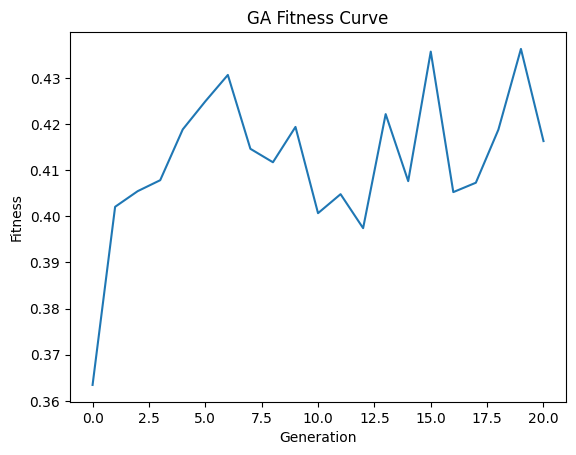

In [ ]:
plt.plot(ga_selector.history["fitness"])
plt.title("GA Fitness Curve")
plt.xlabel("Generation")
plt.ylabel("Fitness")
plt.show()

In [ ]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_ga, y_train)

y_pred = model.predict(X_val_ga)
y_prob = model.predict_proba(X_val_ga)[:,1]

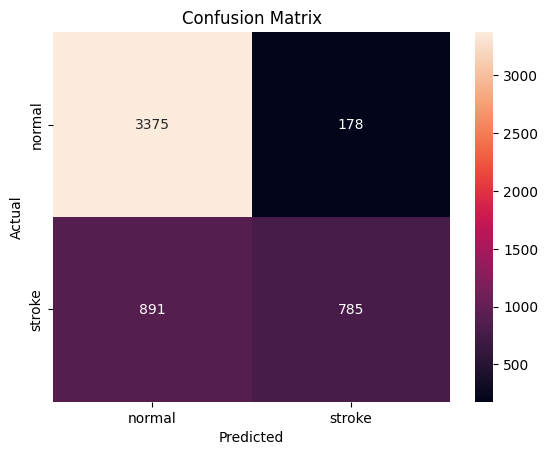

In [ ]:
cm = confusion_matrix(y_val, y_pred)

sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["normal", "stroke"],
            yticklabels=["normal", "stroke"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
print(classification_report(y_pred,y_val))

              precision    recall  f1-score   support

           0       0.95      0.79      0.86      4266
           1       0.47      0.82      0.59       963

    accuracy                           0.80      5229
   macro avg       0.71      0.80      0.73      5229
weighted avg       0.86      0.80      0.81      5229



In [ ]:
print(accuracy_score(y_pred,y_val))

0.7955632052017594


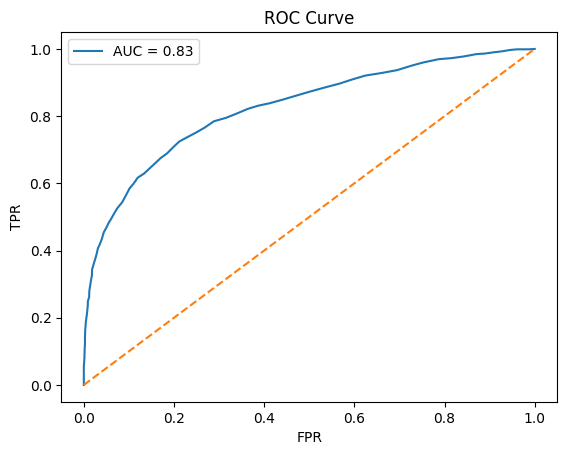

In [ ]:
fpr, tpr, _ = roc_curve(y_val, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [ ]:
save_path = "/content/drive/MyDrive/brain_stroke_model/"
os.makedirs(save_path, exist_ok=True)

with open(os.path.join(save_path, "rf_model.pkl"), "wb") as f:
    pickle.dump(model, f)

with open(os.path.join(save_path, "pca.pkl"), "wb") as f:
    pickle.dump(pca, f)

with open(os.path.join(save_path, "ga_selector.pkl"), "wb") as f:
    pickle.dump(ga_selector, f)

print("Full pipeline saved!")

Full pipeline saved!
